# Setup

In [ ]:
# Заставляем ноутбук обновлять импорты автоматически
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

from hydra.utils import instantiate
from omegaconf import OmegaConf


# 1. Вычисляем корень проекта ОДИН РАЗ
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 2. Инициализируем Hydra и резолверы
from src.utils.notebook_setup import init_nlp_notebook #noqa E402


cfg = init_nlp_notebook()
from src.utils.logger import setup_logging #noqa E402


setup_logging()

# 3. Трюк: принудительно подменяем переменную paths, если она не разрешилась
if "paths" not in cfg:
    cfg.paths = OmegaConf.create()
cfg.paths.data_dir = str(PROJECT_ROOT / "data")

# 4. Инициализируем токенизатор
tokenizer = instantiate(cfg.model.tokenizer).build()
print(f"Environment ready. Root: {PROJECT_ROOT}")
# У генеративных HF моделей параметр обычно называется name_or_path или model_name_or_path
print(f"Model: {cfg.model.model_name}")

NLP Environment ready. Root: c:\nlp_template_decoder


c:\nlp_template_decoder\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-07-26 00:41:02] INFO [src.core.models.tokenization:39] Загрузка токенизатора: HuggingFaceM4/tiny-random-LlamaForCausalLM


[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got -1. This may result in unexpected behavior.


Environment ready. Root: c:\nlp_template_decoder
Model: HuggingFaceM4/tiny-random-LlamaForCausalLM


# Data Loading

In [2]:
from src.core.data.builder import NLPDataModule


# Инициализируем универсальный DataModule
datamodule = NLPDataModule(data_cfg=cfg.data, tokenizer=tokenizer)

# Запускаем загрузку и применение трансформаций
datamodule.prepare_data()

# Загружаем обработанный датасет в память (stage="fit")
datamodule.setup(stage="fit")

dataset = datamodule.train_dataset
print(f"Dataset schema: {dataset.column_names}")
print(f"Train size: {len(dataset)} examples")

[2026-07-26 00:41:06] INFO [src.core.data.builder:57] Начинаем загрузку и применение трансформаций...
[2026-07-26 00:41:06] INFO [src.core.data.fetcher:134] HF датасет найден локально: c:\nlp_template_decoder\data/raw\HuggingFaceH4_testing_alpaca_small
[2026-07-26 00:41:07] INFO [src.core.data.transforms:284] Применение пайплайна очистки текста...


Cleaning text (num_proc=4): 100%|██████████| 80/80 [00:03<00:00, 20.90 examples/s]

[2026-07-26 00:41:10] INFO [src.core.data.transforms:188] Применение валидации записей (Pydantic)...



Validating prompt+completion records (num_proc=4): 100%|██████████| 80/80 [00:04<00:00, 19.65 examples/s]
Filter (num_proc=4): 100%|██████████| 80/80 [00:04<00:00, 18.96 examples/s]

[2026-07-26 00:41:19] INFO [src.core.data.transforms:229] Валидация завершена: 80 -> 80 записей
[2026-07-26 00:41:19] INFO [src.core.data.transforms:54] Применение токенизации...


...

[2026-07-26 00:42:10] INFO [src.core.data.transforms:229] Валидация завершена: 10 -> 10 записей
[2026-07-26 00:42:10] INFO [src.core.data.transforms:54] Применение токенизации...



Filtering > 256 tokens (num_proc=4): 100%|██████████| 10/10 [00:04<00:00,  2.45 examples/s]

[2026-07-26 00:42:24] INFO [src.core.data.transforms:111] Отфильтровано по длине: 10 -> 10



Saving the dataset (1/1 shards): 100%|██████████| 10/10 [00:00<00:00, 1428.58 examples/s]

[2026-07-26 00:42:24] INFO [src.core.data.builder:102] Данные успешно обработаны и сохранены в c:\nlp_template_decoder\data/processed\sft_dataset_processed_b79be0ab
Dataset schema: ['input_ids', 'attention_mask', 'prompt_len']
Train size: 79 examples


# Tokenization & Chat Template Check

In [3]:
sample = dataset[0]

# Проверяем, что датасет действительно прошел токенизацию
if "input_ids" in sample:
    print("--- Данные успешно токенизированы ---")
    tokens = sample["input_ids"]

    print("--- Round-Trip (Декодированный текст) ---")
    # Обязательно смотрим со спец-токенами для проверки Chat Template и склейки
    decoded_text = tokenizer.decode(tokens, skip_special_tokens=False)
    print(decoded_text[:500])
else:
    print(f"Ошибка: ожидались 'input_ids', но получена схема: {sample.keys()}")

--- Данные успешно токенизированы ---
--- Round-Trip (Декодированный текст) ---
Write an essay summarizing and explaining the following topics.

- The role of social media
- Impact of fake news
Social media has become increasingly instrumental in our daily lives, and its influence has been especially profound in news dissemination. The prevalence of fake news, however, has raised serious concerns about the veracity of information being shared. By spreading untruths and misleading information, those who seek to manipulate public opinion have found a powerful virtual platform


# Sequence Length Analysis

Медиана:         63 токенов
95-й перцентиль: 184 токенов
99-й перцентиль: 216 токенов
Максимум:        238 токенов
Обрезается при max_length=256: 0 примеров (0.0%)


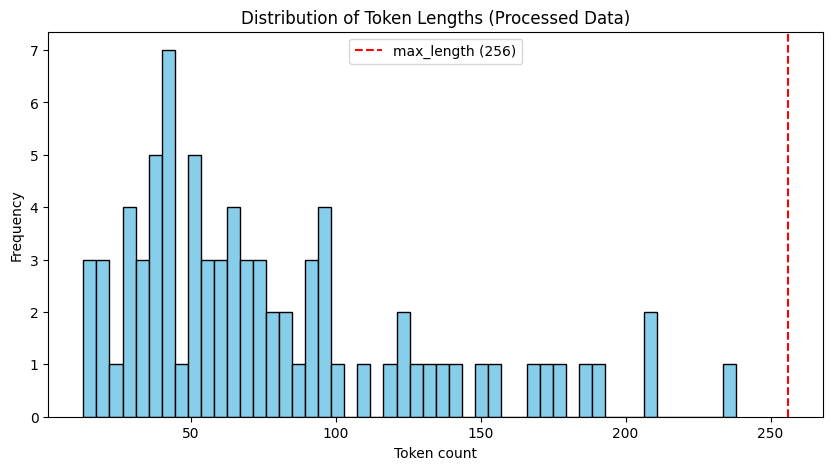

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Датасет уже прошел токенизацию, поэтому мы просто извлекаем длины готовых последовательностей
# Берем первые 1000 записей (или меньше, если датасет короче), чтобы не перегружать память
sample_size = min(1000, len(dataset))
lengths = [len(dataset[i]["input_ids"]) for i in range(sample_size)]

print(f"Медиана:         {np.median(lengths):.0f} токенов")
print(f"95-й перцентиль: {np.percentile(lengths, 95):.0f} токенов")
print(f"99-й перцентиль: {np.percentile(lengths, 99):.0f} токенов")
print(f"Максимум:        {max(lengths)} токенов")

max_len = cfg.data.get("max_length", 2048)

# Так как пайплайн уже отработал, если применялся LengthFilterTransform или SequencePackingTransform,
# то количество обрезанных примеров здесь должно быть равно 0.
# Это отличный sanity check того, что трансформации работают корректно!
cut_off_count = sum(1 for l in lengths if l > max_len) #noqa E741
print(f"Обрезается при max_length={max_len}: {cut_off_count} примеров ({cut_off_count/len(lengths)*100:.1f}%)")

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Token Lengths (Processed Data)")
plt.xlabel("Token count")
plt.ylabel("Frequency")
plt.axvline(max_len, color='red', linestyle='dashed', linewidth=1.5, label=f'max_length ({max_len})')
plt.legend()
plt.show()

# Artifact & Noise Identification

In [ ]:
import re

import pandas as pd


# Декодируем токены обратно в текст для анализа мусора
sample_size = min(1000, len(dataset))
sample_texts = [
    tokenizer.decode(dataset[i]["input_ids"], skip_special_tokens=True)
    for i in range(sample_size)
]

# Паттерны для поиска грязи
noise_patterns = {
    "extra_whitespace": r"\s{3,}",
    "html_tags": r"<[^>]+>",
    "non_printable": r"[^\x20-\x7E\u0400-\u04FF\n]",
    "urls": r"http[s]?://\S+"
}

def analyze_noise(text_list):
    stats = {}
    if not text_list:
        return dict.fromkeys(noise_patterns, 0.0)
    for name, pattern in noise_patterns.items():
        count = sum(1 for text in text_list if re.search(pattern, text))
        stats[name] = count / len(text_list)
    return stats

noise_report = analyze_noise(sample_texts)

df_noise = pd.DataFrame.from_dict(noise_report, orient='index', columns=['percentage'])

# Для наглядности отформатируем вывод в реальные проценты
df_noise['percentage'] = df_noise['percentage'].apply(lambda x: f"{x * 100:.2f}%")

print("--- Noise Artifacts Report (PROCESSED DATA) ---")
print(df_noise)

--- Noise Artifacts Report (PROCESSED DATA) ---
                 percentage
extra_whitespace      0.00%
html_tags             0.00%
non_printable         7.59%
urls                  0.00%
